In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score

In [3]:
# Import data
data = pd.read_csv("Attrition.csv")
data.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,...,1.0,Y,11,8,0,1.0,6,1,0,0
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,...,0.0,Y,23,8,1,6.0,3,5,1,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,...,1.0,Y,15,8,3,5.0,2,5,0,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,...,3.0,Y,11,8,3,13.0,5,8,7,5
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,...,4.0,Y,12,8,2,9.0,2,6,0,4


In [4]:
#Attrition is my target varibale
data.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'Department', 'DistanceFromHome',
       'Education', 'EducationField', 'EmployeeCount', 'EmployeeID', 'Gender',
       'JobLevel', 'JobRole', 'MaritalStatus', 'MonthlyIncome',
       'NumCompaniesWorked', 'Over18', 'PercentSalaryHike', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

In [5]:
data.dtypes

Age                          int64
Attrition                   object
BusinessTravel              object
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeID                   int64
Gender                      object
JobLevel                     int64
JobRole                     object
MaritalStatus               object
MonthlyIncome                int64
NumCompaniesWorked         float64
Over18                      object
PercentSalaryHike            int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears          float64
TrainingTimesLastYear        int64
YearsAtCompany               int64
YearsSinceLastPromotion      int64
YearsWithCurrManager         int64
dtype: object

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked      

In [7]:
#Null value
data.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeID                  0
Gender                      0
JobLevel                    0
JobRole                     0
MaritalStatus               0
MonthlyIncome               0
NumCompaniesWorked         19
Over18                      0
PercentSalaryHike           0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           9
TrainingTimesLastYear       0
YearsAtCompany              0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

In [8]:
data.TotalWorkingYears           

0        1.0
1        6.0
2        5.0
3       13.0
4        9.0
        ... 
4405    10.0
4406    10.0
4407     5.0
4408    10.0
4409     NaN
Name: TotalWorkingYears, Length: 4410, dtype: float64

In [9]:
# See data labels
for i in data.columns:
    print("*******************")
    print()
    print(set(data[i].tolist()))
    print()

*******************

{18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60}

*******************

{'No', 'Yes'}

*******************

{'Non-Travel', 'Travel_Rarely', 'Travel_Frequently'}

*******************

{'Research & Development', 'Human Resources', 'Sales'}

*******************

{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29}

*******************

{1, 2, 3, 4, 5}

*******************

{'Human Resources', 'Marketing', 'Life Sciences', 'Medical', 'Technical Degree', 'Other'}

*******************

{1}

*******************

{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75

In [10]:
# data['NumCompaniesWorked'].fillna(data['NumCompaniesWorked'].median(),inplace=True)
# data['TotalWorkingYears'].fillna(data['TotalWorkingYears'].median(),inplace=True)
data['NumCompaniesWorked'] = data['NumCompaniesWorked'].fillna(data['NumCompaniesWorked'].median())
data['TotalWorkingYears'] = data['TotalWorkingYears'].fillna(data['TotalWorkingYears'].median())


In [11]:
data.isnull().sum()

Age                        0
Attrition                  0
BusinessTravel             0
Department                 0
DistanceFromHome           0
Education                  0
EducationField             0
EmployeeCount              0
EmployeeID                 0
Gender                     0
JobLevel                   0
JobRole                    0
MaritalStatus              0
MonthlyIncome              0
NumCompaniesWorked         0
Over18                     0
PercentSalaryHike          0
StandardHours              0
StockOptionLevel           0
TotalWorkingYears          0
TrainingTimesLastYear      0
YearsAtCompany             0
YearsSinceLastPromotion    0
YearsWithCurrManager       0
dtype: int64

In [12]:
#Encoding categorical
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked      

In [13]:
# ENcoding in one go
cat_cols = ['Attrition','BusinessTravel','Department','EducationField','Gender','JobRole','MaritalStatus']
for col in cat_cols:
    le = LabelEncoder()
    data[col]=le.fit_transform(data[col])
data.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,0,2,2,6,2,1,1,1,0,...,1.0,Y,11,8,0,1.0,6,1,0,0
1,31,1,1,1,10,1,1,1,2,0,...,0.0,Y,23,8,1,6.0,3,5,1,4
2,32,0,1,1,17,4,4,1,3,1,...,1.0,Y,15,8,3,5.0,2,5,0,3
3,38,0,0,1,2,5,1,1,4,1,...,3.0,Y,11,8,3,13.0,5,8,7,5
4,32,0,2,1,10,1,3,1,5,1,...,4.0,Y,12,8,2,9.0,2,6,0,4


In [14]:
data.nunique()

Age                          43
Attrition                     2
BusinessTravel                3
Department                    3
DistanceFromHome             29
Education                     5
EducationField                6
EmployeeCount                 1
EmployeeID                 4410
Gender                        2
JobLevel                      5
JobRole                       9
MaritalStatus                 3
MonthlyIncome              1349
NumCompaniesWorked           10
Over18                        1
PercentSalaryHike            15
StandardHours                 1
StockOptionLevel              4
TotalWorkingYears            40
TrainingTimesLastYear         7
YearsAtCompany               37
YearsSinceLastPromotion      16
YearsWithCurrManager         18
dtype: int64

In [15]:
data['Age'].unique()

array([51, 31, 32, 38, 46, 28, 29, 25, 45, 36, 55, 47, 37, 21, 35, 26, 50,
       53, 42, 44, 49, 18, 41, 39, 58, 33, 43, 52, 27, 30, 54, 40, 23, 48,
       57, 34, 24, 22, 56, 60, 19, 20, 59])

In [16]:
# Drop columns
# data.drop('EmployeeCount', axis = 1, inplace = True)
# data.drop('Over18',axis = 1, inplace = True)
# data.drop('StandardHours',axis = 1, inplace = True)
# data.drop('EmployeeID',axis = 1, inplace = True)
data.drop(['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeID'], axis=1, inplace=True, errors='ignore')


In [17]:
data

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,0,2,2,6,2,1,0,1,0,1,131160,1.0,11,0,1.0,6,1,0,0
1,31,1,1,1,10,1,1,0,1,6,2,41890,0.0,23,1,6.0,3,5,1,4
2,32,0,1,1,17,4,4,1,4,7,1,193280,1.0,15,3,5.0,2,5,0,3
3,38,0,0,1,2,5,1,1,3,1,1,83210,3.0,11,3,13.0,5,8,7,5
4,32,0,2,1,10,1,3,1,1,7,2,23420,4.0,12,2,9.0,2,6,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4405,42,0,2,1,5,4,3,0,1,6,2,60290,3.0,17,1,10.0,5,3,0,2
4406,29,0,2,1,2,4,3,1,1,2,0,26790,2.0,15,0,10.0,2,3,0,2
4407,25,0,2,1,25,2,1,1,2,7,1,37020,0.0,20,0,5.0,4,4,1,2
4408,42,0,2,2,18,2,3,1,1,2,0,23980,0.0,14,1,10.0,2,9,7,8


In [18]:
# Model building and prediction


In [19]:
# Split the data into independent and target variable
x = data.drop(['Attrition'], axis=1)
y = data['Attrition']
x

,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,2,2,6,2,1,0,1,0,1,131160,1.0,11,0,1.0,6,1,0,0
1,31,1,1,10,1,1,0,1,6,2,41890,0.0,23,1,6.0,3,5,1,4
2,32,1,1,17,4,4,1,4,7,1,193280,1.0,15,3,5.0,2,5,0,3
3,38,0,1,2,5,1,1,3,1,1,83210,3.0,11,3,13.0,5,8,7,5
4,32,2,1,10,1,3,1,1,7,2,23420,4.0,12,2,9.0,2,6,0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4405,42,2,1,5,4,3,0,1,6,2,60290,3.0,17,1,10.0,5,3,0,2
4406,29,2,1,2,4,3,1,1,2,0,26790,2.0,15,0,10.0,2,3,0,2
4407,25,2,1,25,2,1,1,2,7,1,37020,0.0,20,0,5.0,4,4,1,2
4408,42,2,2,18,2,3,1,1,2,0,23980,0.0,14,1,10.0,2,9,7,8


In [20]:
y

0       0
1       1
2       0
3       0
4       0
       ..
4405    0
4406    0
4407    0
4408    0
4409    0
Name: Attrition, Length: 4410, dtype: int64

In [21]:
# Split the data into train and test
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2,random_state=12)

In [22]:
x_train

,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
329,52,2,1,29,3,1,1,2,4,1,29420,8.0,11,1,9.0,1,5,1,4
2975,26,2,1,8,3,3,1,2,3,2,157870,1.0,12,2,8.0,5,8,7,4
4396,45,2,1,18,1,1,0,2,8,1,58110,0.0,14,0,25.0,4,24,1,7
3495,39,1,2,1,3,2,1,2,0,0,67550,7.0,14,1,21.0,2,18,11,5
2580,34,1,1,9,4,1,0,2,4,1,26250,1.0,12,3,16.0,4,15,6,11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3916,47,0,1,3,2,1,0,2,7,1,39550,7.0,12,1,4.0,5,1,0,0
1283,29,2,1,28,4,1,0,1,8,1,48410,0.0,11,0,6.0,3,5,0,4
3714,39,0,1,2,4,3,1,2,4,2,43810,2.0,15,2,11.0,1,1,0,0
3325,42,2,1,18,1,5,0,2,6,1,199990,2.0,23,1,17.0,6,5,1,3


In [23]:
x_test

,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
2944,32,2,1,10,1,3,1,1,7,2,23420,4.0,12,2,9.0,2,6,0,4
2905,38,2,1,1,2,3,1,4,2,0,64720,0.0,12,0,17.0,4,16,5,13
2152,39,2,1,18,2,1,1,2,2,2,28360,0.0,20,0,6.0,3,5,0,3
493,50,0,0,2,2,1,1,1,2,1,36880,0.0,11,0,19.0,3,18,0,13
2456,30,1,2,9,3,1,1,1,5,2,95820,0.0,12,1,10.0,2,9,0,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
438,45,0,1,8,1,1,1,2,7,1,33190,1.0,12,1,9.0,3,9,0,8
1030,35,0,2,10,1,1,0,2,5,0,43230,2.0,18,3,15.0,3,7,1,7
3201,29,1,2,2,4,1,1,4,0,0,64990,1.0,18,3,10.0,3,10,2,8
968,32,1,2,1,1,2,1,2,2,1,88580,6.0,16,1,10.0,2,5,1,3


In [24]:
y_train

329     0
2975    1
4396    0
3495    1
2580    0
       ..
3916    0
1283    0
3714    1
3325    0
1414    0
Name: Attrition, Length: 3528, dtype: int64

In [25]:
y_test

2944    0
2905    0
2152    1
493     0
2456    0
       ..
438     0
1030    0
3201    0
968     0
2278    0
Name: Attrition, Length: 882, dtype: int64

In [26]:
# Feature scaling - to scale/normalize into same scale

In [27]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [28]:
x_train_scaled

array([[ 1.66450607,  0.59124673, -0.49675166, ..., -0.32752067,
        -0.37982643, -0.03291494],
       [-1.19545371,  0.59124673, -0.49675166, ...,  0.1582527 ,
         1.46340281, -0.03291494],
       [ 0.8945169 ,  0.59124673, -0.49675166, ...,  2.74904404,
        -0.37982643,  0.81264755],
       ...,
       [ 0.23452618, -2.4274486 , -0.49675166, ..., -0.97521851,
        -0.68703131, -1.1603316 ],
       [ 0.56452154,  0.59124673, -0.49675166, ..., -0.32752067,
        -0.37982643, -0.31476911],
       [-0.31546609, -0.91810093, -0.49675166, ..., -0.32752067,
        -0.07262156, -1.1603316 ]])

In [29]:
# Model training - without hyperparameter
model = LogisticRegression()
model.fit(x_train_scaled, y_train)

LogisticRegression()

In [30]:
# Predict training
y_train_pred = model.predict(x_train_scaled)

In [31]:
#Predict Test
y_test_pred = model.predict(x_test_scaled)

In [32]:
# Model EValuation

In [33]:
test_accuracy = accuracy_score(y_test,y_test_pred)
test_accuracy

0.8605442176870748

In [34]:
train_accuracy = accuracy_score(y_train,y_train_pred)
train_accuracy

0.8378684807256236

In [35]:
# Confusion matrix

In [36]:
cm=confusion_matrix(y_test,y_test_pred)
cm

array([[751,   5],
       [118,   8]])

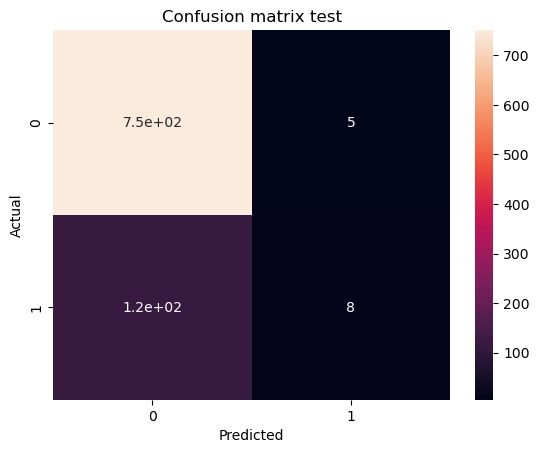

In [37]:
sns.heatmap(cm, annot = True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion matrix test")
plt.show()

In [38]:
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()

In [39]:
tn

np.int64(751)

In [40]:
#REcall
recall = tp/(tp+fn)
recall

np.float64(0.06349206349206349)

In [41]:
#Prcision
precision = tp/(tp+fp)
precision

np.float64(0.6153846153846154)

In [42]:
f1_score = (2* (precision*recall))/(precision + recall)
f1_score

np.float64(0.11510791366906474)

In [47]:
# ROC and AUC cureve
y_test_prob = model.predict_proba(x_test_scaled)[:,1]
y_test_prob

array([0.295871  , 0.01531487, 0.20326779, 0.0147042 , 0.1118385 ,
       0.20392707, 0.20966254, 0.11965018, 0.31678677, 0.35955908,
       0.05310424, 0.02831374, 0.09585962, 0.11568679, 0.08506084,
       0.18547623, 0.08860305, 0.04442399, 0.31361929, 0.31850777,
       0.295871  , 0.03019994, 0.45404683, 0.35874577, 0.21027467,
       0.09390323, 0.14766506, 0.26487868, 0.09580043, 0.29585875,
       0.07901686, 0.12637765, 0.06315911, 0.30997666, 0.08508097,
       0.14962239, 0.19308042, 0.02715185, 0.07363694, 0.26382086,
       0.29440376, 0.0429285 , 0.1256168 , 0.0689844 , 0.0714589 ,
       0.23785745, 0.42182372, 0.39470687, 0.00974917, 0.08567401,
       0.07172808, 0.07345271, 0.16965436, 0.01181732, 0.03749536,
       0.27231384, 0.09136173, 0.07861561, 0.06747784, 0.18166377,
       0.19452727, 0.45791732, 0.09565497, 0.11737841, 0.25434873,
       0.32132934, 0.19178538, 0.39902066, 0.09390336, 0.0425011 ,
       0.42003545, 0.27978299, 0.07379089, 0.29585875, 0.15202

In [49]:
fpr, tpr, thresholds = roc_curve(y_test, y_test_prob)

In [50]:
fpr


array([0.        , 0.00132275, 0.00132275, 0.00132275, 0.00132275,
       0.00396825, 0.00396825, 0.00529101, 0.00529101, 0.00661376,
       0.00661376, 0.01190476, 0.01455026, 0.01455026, 0.01719577,
       0.01719577, 0.01984127, 0.01984127, 0.02116402, 0.02116402,
       0.02380952, 0.02777778, 0.03042328, 0.03042328, 0.03439153,
       0.03439153, 0.03571429, 0.03571429, 0.03571429, 0.03835979,
       0.03835979, 0.03968254, 0.03968254, 0.04100529, 0.04100529,
       0.04232804, 0.04232804, 0.04497354, 0.05291005, 0.0542328 ,
       0.05687831, 0.05820106, 0.06084656, 0.06084656, 0.06084656,
       0.06481481, 0.06481481, 0.06481481, 0.06878307, 0.06878307,
       0.07142857, 0.07142857, 0.07275132, 0.07275132, 0.07407407,
       0.07936508, 0.08333333, 0.08333333, 0.08597884, 0.08730159,
       0.08730159, 0.09126984, 0.09126984, 0.09126984, 0.09259259,
       0.09259259, 0.09391534, 0.09391534, 0.09656085, 0.09656085,
       0.0978836 , 0.0978836 , 0.10449735, 0.10449735, 0.11243

In [52]:
auc = roc_auc_score(y_test,y_test_prob)
auc

np.float64(0.7188838498362308)

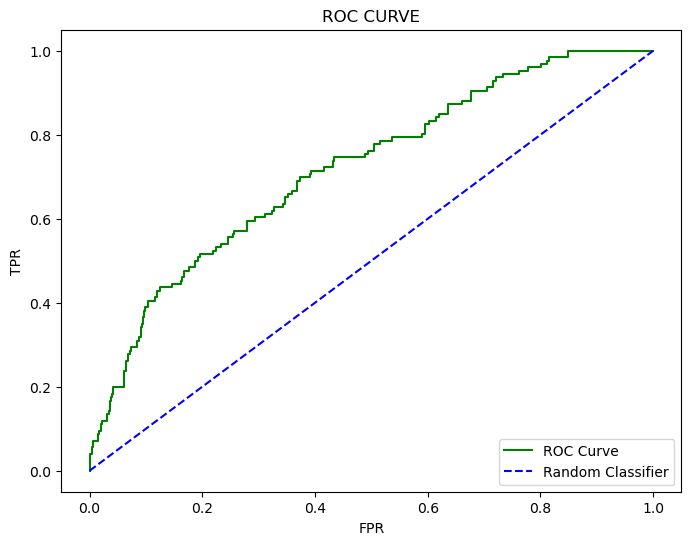

In [56]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, color='green', label='ROC Curve')
plt.plot([0,1], [0,1], color='blue', linestyle='--', label='Random Classifier')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC CURVE")
plt.legend(loc='lower right')
plt.show()


In [57]:
data.Attrition.value_counts()

Attrition
0    3699
1     711
Name: count, dtype: int64